# MNIST Denoising Autoencoder

## Import Libraries

In [1]:
import os
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

## Load Dataset

In [2]:
train_dir = "dataset/mnist_png/training"
test_dir = "dataset/mnist_png/testing"

## Data Preprocessing

In [3]:
def load_images(data_dir):
    images = []

    for digit in sorted(os.listdir(data_dir)):
        digit_path = os.path.join(data_dir, digit)

        if not os.path.isdir(digit_path):
            continue

        for file in os.listdir(digit_path):
            image_path = os.path.join(digit_path, file)

            image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

            image = image.astype("float32") / 255.0

            image = image.reshape(28, 28, 1)

            images.append(image)

    return np.array(images)

In [4]:
x_train = load_images(train_dir)
x_test = load_images(test_dir)

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Training Images : (60000, 28, 28, 1)
Testing Images  : (10000, 28, 28, 1)


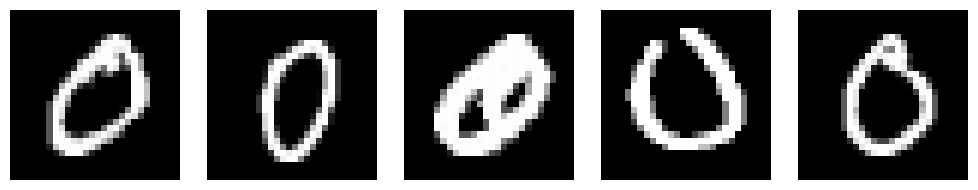

In [5]:
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Add Gaussian Noise

In [6]:
np.random.seed(42)

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

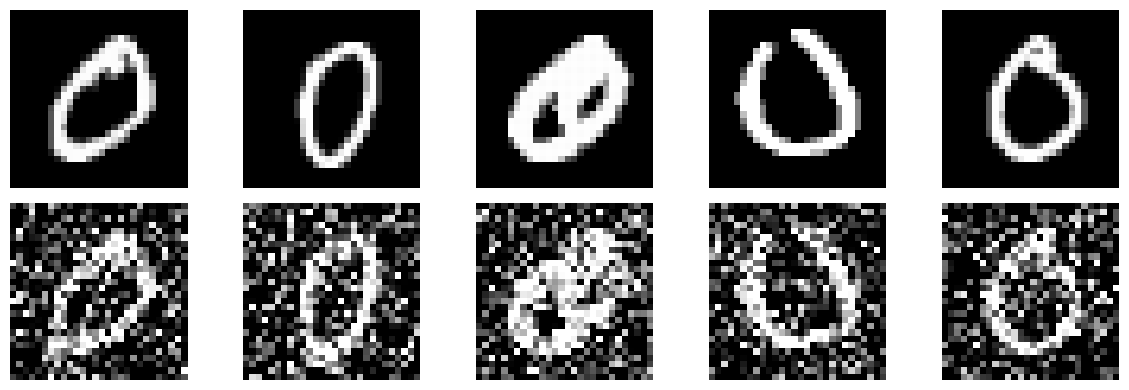

In [7]:
plt.figure(figsize=(12, 4))

for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Build Autoencoder

In [8]:
input_img = layers.Input(shape=(28, 28, 1))

In [9]:
# Encoder

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same")(x)

In [10]:
# Decoder

x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)

x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)

decoded = layers.Conv2D(
    1,
    (3, 3),
    activation="sigmoid",
    padding="same"
)(x)

In [11]:
autoencoder = models.Model(input_img, decoded)

In [12]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

## Train Model

In [14]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - loss: 0.1542 - val_loss: 0.1141
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.1112 - val_loss: 0.1067
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.1054 - val_loss: 0.1026
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - loss: 0.1026 - val_loss: 0.1007
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.1008 - val_loss: 0.0995
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0995 - val_loss: 0.0981
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0985 - val_loss: 0.0973
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - loss: 0.0977 - val_loss: 0.0965
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.0969 - val_loss: 0.0961
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0963 - val_loss: 0.0955
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.0958 - val_loss: 0.0948
Epoch 12/15
469/469 ━━━━━━━━━━

## Evaluate Model

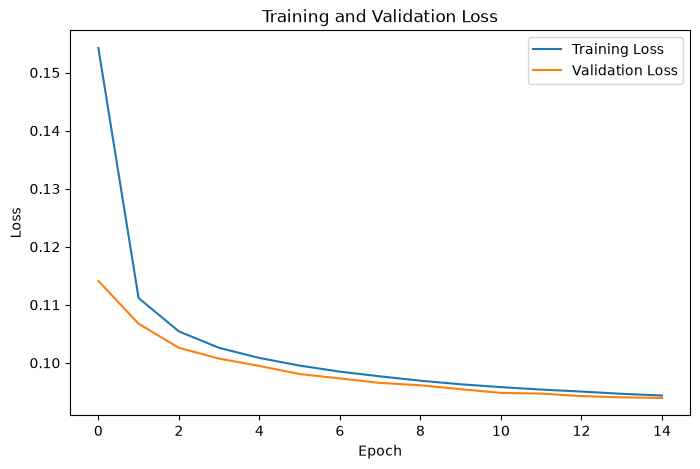

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.savefig("images/loss_curve.png", dpi=300, bbox_inches="tight")

plt.show()

In [16]:
history_df = pd.DataFrame(history.history)
history_df.to_csv("outputs/training_history.csv", index=False)

## Results

In [17]:
decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


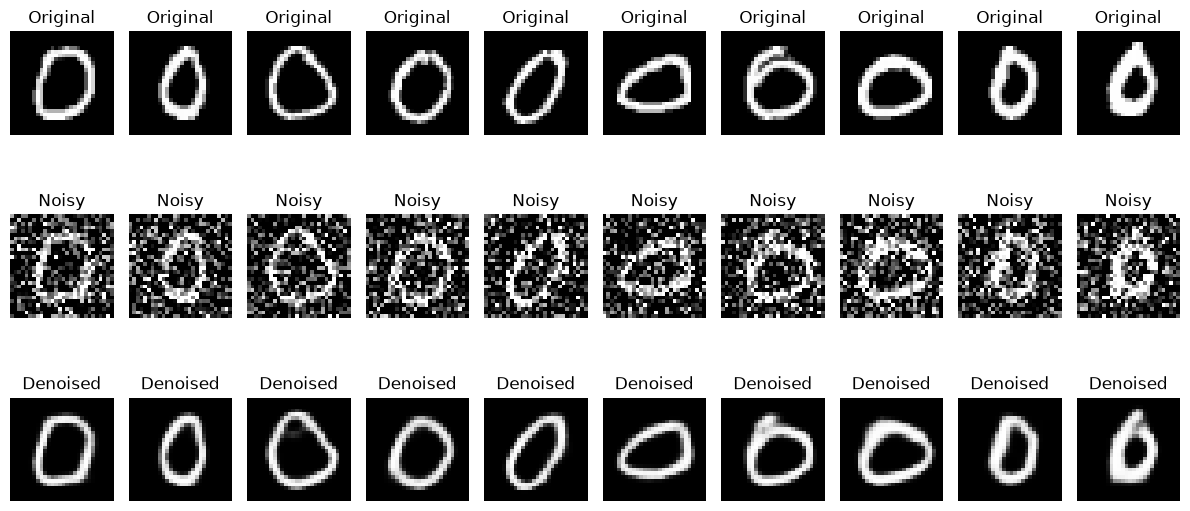

In [18]:
n = 10

plt.figure(figsize=(12, 6))

for i in range(n):

    # Original
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_images[i].squeeze(), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "images/reconstruction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "outputs/sample_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
autoencoder.save("models/autoencoder.keras")

In [20]:
test_loss = autoencoder.evaluate(
    x_test_noisy,
    x_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.0939


## Conclusion

A convolutional denoising autoencoder was trained on the MNIST dataset to reconstruct clean handwritten digit images from noisy inputs. The model successfully learned to remove Gaussian noise while preserving the digit structure. The training and validation losses decreased consistently, indicating stable learning and good generalization on the test dataset.